In [23]:
import sys
exec(open('/data/id11/nanoscope/install_ImageD11_from_git.py').read())
PYTHONPATH = setup_ImageD11_from_git( '/data/projects/drex/Adi/projects/finding_grain_2/analysze_3dxrd','ImageD11') ### replace with where you installed imaged11

sys.path.insert(0, '/data/projects/drex/Adi/projects/oblique/crispy/') ### replace with where you installed crispy.

# Setting path via: 
sys.path.insert(0, /data/projects/drex/Adi/projects/finding_grain_2/analysze_3dxrd/ImageD11 )
# Running from: /data/projects/drex/Adi/projects/finding_grain_2/analysze_3dxrd/ImageD11/ImageD11/__init__.py


In [24]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import crispy
import ImageD11.grain
import matplotlib.pyplot as plt

import pandas as pd
from IPython.display import display, HTML
%matplotlib ipympl

In [50]:
grainfilepath='path_grain_file.h5'  #### replace the path to grains.h5 file after indexing step.
symmetry=225

In [ ]:
grain_map_3dxrd=crispy.GrainMap(grainfilepath,group_name='Fe',symmetry=symmetry)

(<Figure size 900x700 with 1 Axes>,
 <Axes3D: title={'center': 'Voronoi Tesselation of the Polycrystal\nColoring by ipf (view-axis x,y,z = 1.,0.,0.)'}>)

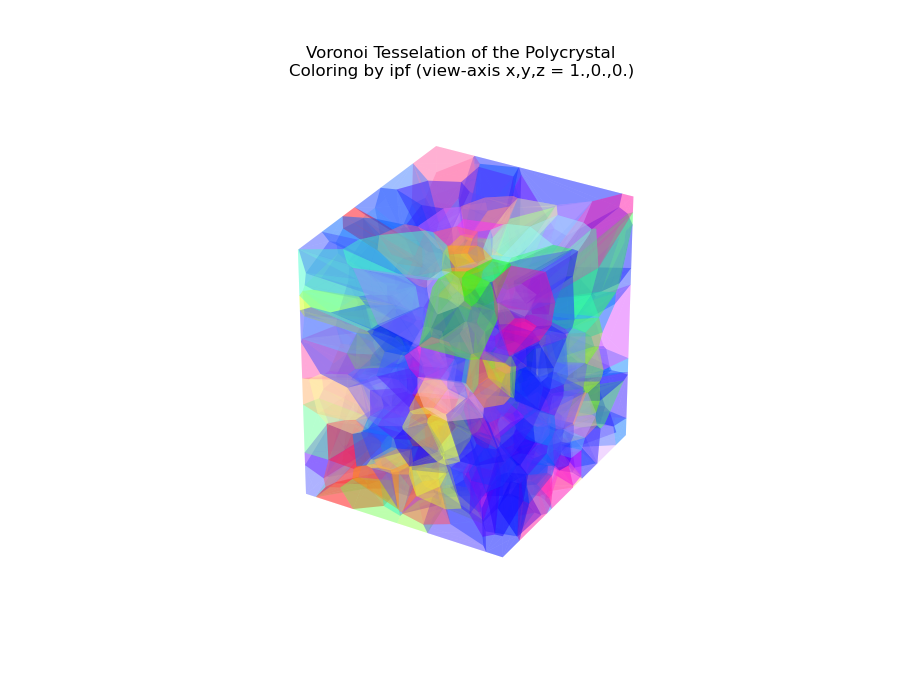

In [41]:
grain_map_3dxrd.colorize( np.eye(3) )
crispy.vizualise.mesh(grain_map_3dxrd) 
#crispy.vizualise.mesh(grain_map_3dxrd,select=[2,4,5]) ### this can be used to identify neighbours for example.

In [28]:
motor_bounds = {
    "mu": (-5, 15),
    "omega": (0, 360.26),
    "chi": (-5, 5),
    "phi": (-5,5),
    "detector_z": (-0.04, 1.96),
    "detector_y": (-0.169, 1.16),
}


In [29]:
goniometer = crispy.dfxm.Goniometer(grain_map_3dxrd,
                        energy=17,
                        detector_distance=5,
                        motor_bounds=motor_bounds,verbose=False)


In [ ]:
goniometer.find_reflections()

In [ ]:
df = goniometer.table_of_reflections()
df.round(3)[:]

,grain id,h,k,l,mu [dgr],omega [dgr],chi [dgr],phi [dgr],2 theta [dgr],eta [dgr],detector_z [mm]
0,0.0,-1.0,1.0,0.0,-41.084,126.272,4.979,4.999,20.726,0.0,1891.899
1,1.0,-1.0,1.0,0.0,-33.497,122.678,4.608,2.664,20.723,0.0,1891.621
2,1.0,1.0,1.0,0.0,10.212,204.182,-3.517,4.395,20.723,0.0,1891.615
3,2.0,-1.0,-1.0,0.0,-43.571,32.284,4.884,-4.155,20.724,0.0,1891.782
4,3.0,-1.0,-1.0,0.0,4.793,349.878,1.806,-4.882,20.722,0.0,1891.513
...,...,...,...,...,...,...,...,...,...,...,...
1030,628.0,1.0,0.0,-1.0,-1.227,296.429,1.056,-0.392,20.723,0.0,1891.623
1031,629.0,-1.0,-1.0,0.0,1.787,353.065,3.660,0.417,20.724,0.0,1891.759
1032,629.0,1.0,0.0,-1.0,-18.889,233.301,2.207,-3.216,20.726,0.0,1891.947
1033,631.0,-1.0,0.0,-1.0,-42.005,59.468,2.021,1.457,20.723,0.0,1891.679


In [30]:
goniometer.polycrystal.tesselate()

In [32]:
### if you want to look at neibhours of specific grains .
goniometer.polycrystal.neighbours[9]

array([ 46, 103, 109, 120, 128, 155, 221, 250, 294, 304, 489, 582, 608])

In [ ]:
### get the available reflections
goniometer.polycrystal.grains[0].dfxm

{'hkl': array([[-1.],
        [ 1.],
        [ 0.]]),
 'mu': array([-41.08389342]),
 'omega': array([126.27200992]),
 'chi': array([4.9794122]),
 'phi': array([4.99929885]),
 'residual': array([6.72262041e-06]),
 'theta': array([10.36281337])}